## 01 — EDA sobre dataset_final autoritativo (Canarias)

Fuente única: `data/outputs/dataset_final.csv` generado por `scripts/07_fusion_dataset_final.py` (1581 secciones x 36 cols, 0 nulos, CUSEC 10 dígitos, imputación por mediana). Este notebook NO reconstruye merges ni reimputa: solo EDA + feature-set + K-Means exploratorio K=4. Ver `data/reports/07_metadata.json` para trazabilidad.

### 0. Instalación de dependencias

Instala `../requirements.txt` (pandas 3.0.3, geopandas 1.1.3, osmnx 2.1.1, scikit-learn 1.9.0, folium 0.20.0, etc.). Solo necesario la primera vez o si cambia el entorno.

In [1]:
# Dependencias fijadas en ../requirements.txt (no instalar en cada ejecución).
# Solo primera vez o cambio de entorno, descomentar:
# %pip install -r ../requirements.txt


In [2]:
import os
import pandas as pd
import unicodedata
from pathlib import Path

DATASET_FINAL_CSV = Path('../data/outputs/dataset_final.csv')
DATASET_FINAL_GPKG = Path('../data/outputs/dataset_final.gpkg')
METADATA_07 = Path('../data/reports/07_metadata.json')

# CANONICO: dataset_final 36 cols (script 07). Sin alias legacy ni duplicados.
# Los nombres legacy (distminhospitalkm, poblaciontotal, cusec...) están DEPRECATED.
# Todo el EDA usa nombres autoritativos: CUSEC, dist_min_hospital_km, poblacion_total, etc.

def load_all_csv_from_data_folder(directory_path='../data'):
    raise RuntimeError('DEPRECATED: usa load_dataset_final(). El EDA solo lee data/outputs/dataset_final.csv (script 07).')

def load_dataset_final(csv_path=None):
    cands = [Path(csv_path) if csv_path else None, DATASET_FINAL_CSV, Path('data/outputs/dataset_final.csv'), Path('../data/outputs/dataset_final.csv')]
    csv_path = next((p for p in cands if p is not None and p.exists()), DATASET_FINAL_CSV)
    assert csv_path.exists(), f'No existe {csv_path}. Ejecuta: python scripts/07_fusion_dataset_final.py'
    df = pd.read_csv(csv_path, dtype={'CUSEC': str})
    assert len(df) == 1581, f'Filas inesperadas: {len(df)}'
    assert df['CUSEC'].str.len().eq(10).all(), 'CUSEC no normalizado a 10 digitos'
    assert not df['CUSEC'].duplicated().any(), 'CUSEC duplicados'
    assert df.isna().sum().sum() == 0, 'dataset_final debe tener 0 nulos (imputado en script 07)'
    assert len(df.columns) == 36, f'Columnas inesperadas: {len(df.columns)} (esperado 36)'
    print(f'[OK] dataset_final: {df.shape} nulos=0 desde {csv_path}')
    return df

def add_legacy_aliases(df):
    # DEPRECATED: no duplicar columnas. Devuelve copia tal cual para compatibilidad.
    import warnings
    warnings.warn('add_legacy_aliases DEPRECATED: devuelve df sin alias (36 cols). Actualiza referencias legacy.', DeprecationWarning)
    return df.copy()

def clean_column_name(col_name):
    col_name = str(col_name).lower()
    col_name = ''.join(c for c in col_name if c.isalnum() or c.isspace())
    col_name = unicodedata.normalize('NFKD', col_name).encode('ascii', 'ignore').decode('utf-8')
    col_name = col_name.replace(' ', '_')
    col_name = ''.join(c for c in col_name if c.isalnum() or c == '_')
    col_name = '_'.join(filter(None, col_name.split('_')))
    return col_name


### 1. Carga autoritativa (`data/outputs/dataset_final.csv`, script 07)

In [3]:
IN_COLAB = False
print('Local execution: Google Drive mount skipped (dataset_final es local y versionado).')

df_final = load_dataset_final(DATASET_FINAL_CSV)
merged_df = df_final.copy()  # CANONICO 36 cols, sin alias
ground_truth_dataframes = {'dataset_final': df_final.copy()}
normalized_dataframes = {'dataset_final': merged_df.copy()}
print(f"merged_df (canonico 36 cols): {merged_df.shape}")
display(merged_df.head())


Local execution: Google Drive mount skipped (dataset_final es local y versionado).
[OK] dataset_final: (1581, 36) nulos=0 desde ..\data\outputs\dataset_final.csv
merged_df (canonico 36 cols): (1581, 36)


,CUSEC,isla,centroid_lon,centroid_lat,dist_min_hospital_km,dist_min_cs_km,dist_min_farmacia_km,dist_min_colegio_km,dist_min_parada_km,n_paradas_500m,...,pct_activos,pct_estudios_superiores,nivel_estudios_medio,total_viviendas,total_hogares,tamano_medio_hogar,area_km2,perimetro_km,dens_hospitales_km2,dens_paradas_km2
0,3500401006,Lanzarote,-13.552376,28.965145,0.583,0.090,0.301,0.360,0.182,11,...,0.628405,0.230739,2.820623,1218.0,1101.0,2.660909,0.1980,2.2282,25.2525,55.5556
1,3500401007,Lanzarote,-13.549996,28.963791,0.595,0.360,0.238,0.281,0.299,9,...,0.650891,0.276583,2.858328,807.0,735.0,2.610884,0.1050,1.7107,47.6190,85.7143
2,3500401009,Lanzarote,-13.556739,28.959497,0.598,0.722,0.173,0.154,0.078,15,...,0.569328,0.395658,3.046218,690.0,615.0,2.538336,0.0745,1.2745,67.1141,201.3423
3,3500401010,Lanzarote,-13.560099,28.959637,0.588,0.820,0.473,0.123,0.143,11,...,0.615639,0.284294,2.911531,675.0,651.0,2.587692,0.1726,1.7482,28.9687,63.7312
4,3500401011,Lanzarote,-13.559630,28.962244,0.301,0.529,0.335,0.254,0.134,18,...,0.631673,0.263345,2.893238,537.0,486.0,2.713992,0.0502,1.0120,99.6016,358.5657


### 2. Validación de rangos sobre `dataset_final` (36 cols)

- `pct_extranjeros ∈ [0,100]` → ver celda siguiente (conteo real).
- `pct_menor_18 + pct_mayor_65 ≤ 100` → ver celda siguiente.
- `dist_min_* > 0`, `area_km2 > 0` → ver celda siguiente.
- `densidad_real_hab_km2 ≈ poblacion_total / area_km2` → ver §8.
- Sin `outer` ni coberturas parciales: 0 nulos por construcción (script 07).


In [4]:
print("\n--- Validación de rangos sobre dataset_final (36 cols) ---")
import pandas as pd

df = merged_df  # 1581x36 canonico

# 1. pct_extranjeros en [0,100]
if 'pct_extranjeros' in df.columns:
    bad = df[(df['pct_extranjeros'] < 0) | (df['pct_extranjeros'] > 100)]
    print(f"pct_extranjeros fuera [0,100]: {len(bad)}")
    if not bad.empty: display(bad[['CUSEC','isla','pct_extranjeros']].head())

# 2. pct_menor_18 + pct_mayor_65 <= 100
if {'pct_menor_18','pct_mayor_65'}.issubset(df.columns):
    bad = df[(df['pct_menor_18'] + df['pct_mayor_65']) > 100]
    print(f"pct_menor_18+pct_mayor_65>100: {len(bad)}")
    if not bad.empty: display(bad[['CUSEC','pct_menor_18','pct_mayor_65']].head())

# 3. distancias > 0
for c in ['dist_min_hospital_km','dist_min_cs_km','dist_min_farmacia_km','dist_min_colegio_km','dist_min_parada_km']:
    if c in df.columns:
        n_bad = int(((df[c].notna()) & (df[c] <= 0)).sum())
        print(f"{c} <=0: {n_bad} (min={df[c].min():.4f})")

# 4. area_km2 > 0
if 'area_km2' in df.columns:
    n_bad = int((df['area_km2'] <= 0).sum())
    print(f"area_km2 <=0: {n_bad} (min={df['area_km2'].min():.4f})")

# 5. coherencia densidad
if {'densidad_real_hab_km2','poblacion_total','area_km2'}.issubset(df.columns):
    calc = df['poblacion_total'] / df['area_km2']
    disc = (abs(calc - df['densidad_real_hab_km2']) / df['densidad_real_hab_km2'].replace(0, float('nan')) * 100)
    print(f"densidad_real discrepancia mediana: {disc.median():.2f}% | >5%: {int((disc>5).sum())}")
print("\n--- Fin validación ---")



--- Validación de rangos sobre dataset_final (36 cols) ---
pct_extranjeros fuera [0,100]: 0
pct_menor_18+pct_mayor_65>100: 0
dist_min_hospital_km <=0: 0 (min=0.0260)
dist_min_cs_km <=0: 0 (min=0.0080)
dist_min_farmacia_km <=0: 0 (min=0.0050)
dist_min_colegio_km <=0: 0 (min=0.0110)
dist_min_parada_km <=0: 0 (min=0.0020)
area_km2 <=0: 0 (min=0.0085)
densidad_real discrepancia mediana: 0.00% | >5%: 175

--- Fin validación ---


### 3. Validación post-carga de `merged_df`

1. Nulos por columna (esperado: 0 en todas).
2. Duplicados de `CUSEC` → **0** (OK).
3. Cobertura: 1581 CUSECs únicos, por isla en celda anterior.


In [5]:
# Validación post-carga: nulos y duplicados sobre 36 cols canónicas
print("\n--- Análisis de Valores Nulos (dataset_final 36 cols) ---")
print(f"Total nulos en merged_df: {int(merged_df.isna().sum().sum())} (esperado 0)")
bad = merged_df.isna().sum()
bad = bad[bad > 0]
if not bad.empty:
    print(bad.sort_values(ascending=False).head(20))
else:
    print("OK: 0 nulos en las 36 columnas.")
print(f"\nDuplicados CUSEC: {int(merged_df.duplicated('CUSEC').sum())} (esperado 0)")
print(f"CUSEC únicos: {merged_df['CUSEC'].nunique()} / {len(merged_df)}")



--- Análisis de Valores Nulos (dataset_final 36 cols) ---
Total nulos en merged_df: 0 (esperado 0)
OK: 0 nulos en las 36 columnas.

Duplicados CUSEC: 0 (esperado 0)
CUSEC únicos: 1581 / 1581


### 4. Estructura y tipos de `merged_df` (`info` + `describe`)


In [6]:
print("--- Información General del merged_df ---")
merged_df.info()

print("\n--- Resumen Estadístico de Columnas Numéricas ---")
display(merged_df.describe())

print("\n--- Resumen Estadístico de Columnas Categóricas/Objeto ---")
display(merged_df.describe(include='object'))

print("\n--- Conteo de Valores Únicos por Columna (primeras 20 con más nulos o baja cardinalidad) ---")
# Identificar columnas con nulos y/o baja cardinalidad para un mejor análisis
column_info = pd.DataFrame({
    'dtype': merged_df.dtypes,
    'non_null_count': merged_df.count(),
    'null_count': merged_df.isnull().sum(),
    'unique_count': merged_df.nunique()
})

# Ordenar por cantidad de nulos descendente, luego por cardinalidad ascendente
display(column_info.sort_values(by=['null_count', 'unique_count'], ascending=[False, True]).head(20))

--- Información General del merged_df ---
<class 'pandas.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CUSEC                     1581 non-null   str    
 1   isla                      1581 non-null   str    
 2   centroid_lon              1581 non-null   float64
 3   centroid_lat              1581 non-null   float64
 4   dist_min_hospital_km      1581 non-null   float64
 5   dist_min_cs_km            1581 non-null   float64
 6   dist_min_farmacia_km      1581 non-null   float64
 7   dist_min_colegio_km       1581 non-null   float64
 8   dist_min_parada_km        1581 non-null   float64
 9   n_paradas_500m            1581 non-null   int64  
 10  n_hospitales_5km          1581 non-null   int64  
 11  poblacion_total           1581 non-null   float64
 12  pct_extranjeros           1581 non-null   float64
 13  pct_nacidos_extranjero    1581 n

,centroid_lon,centroid_lat,dist_min_hospital_km,dist_min_cs_km,dist_min_farmacia_km,dist_min_colegio_km,dist_min_parada_km,n_paradas_500m,n_hospitales_5km,poblacion_total,...,pct_activos,pct_estudios_superiores,nivel_estudios_medio,total_viviendas,total_hogares,tamano_medio_hogar,area_km2,perimetro_km,dens_hospitales_km2,dens_paradas_km2
count,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,...,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000
mean,-15.886077,28.280583,3.491738,1.964611,1.262222,1.071514,0.532959,9.484503,6.098039,1593.131562,...,0.578583,0.278020,2.824837,773.832068,587.552182,2.601223,9.390580,10.970797,85.512742,127.864490
std,0.953237,0.286832,4.185506,2.232793,1.559393,1.329954,0.838295,10.391418,6.819360,671.531585,...,0.053829,0.116292,0.211616,532.138558,268.932539,0.215310,26.226197,15.470370,192.437464,287.352426
min,-18.086107,27.696747,0.026000,0.008000,0.005000,0.011000,0.002000,0.000000,0.000000,13.000000,...,0.307692,0.051765,2.266334,9.000000,0.000000,1.000000,0.008500,0.482100,0.000000,0.000000
25%,-16.451891,28.088345,0.669000,0.447000,0.273000,0.232000,0.107000,0.000000,1.000000,1159.000000,...,0.546919,0.199533,2.689589,534.000000,429.000000,2.487544,0.122900,1.733300,0.031900,0.000000
50%,-15.778771,28.203158,1.733000,1.147000,0.631000,0.524000,0.210000,6.000000,3.000000,1485.000000,...,0.575814,0.257456,2.796310,673.500000,540.000000,2.624161,0.617800,4.335300,3.150400,8.902700
75%,-15.434350,28.464287,4.697000,2.757000,1.636000,1.493000,0.529000,16.000000,12.000000,1875.000000,...,0.610140,0.328021,2.925855,834.000000,672.000000,2.726908,4.825600,12.814100,69.541000,115.874900
max,-13.450483,29.252336,24.045000,17.344000,11.792000,12.160000,6.361000,90.000000,22.000000,6858.000000,...,1.000000,1.000000,3.523443,6792.000000,2910.000000,3.302772,355.316400,126.027600,2470.588200,3529.411800



--- Resumen Estadístico de Columnas Categóricas/Objeto ---


C:\Users\selen\AppData\Local\Temp\ipykernel_23924\609139172.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(merged_df.describe(include='object'))


,CUSEC,isla
count,1581,1581
unique,1581,7
top,3500401006,Tenerife
freq,1,670



--- Conteo de Valores Únicos por Columna (primeras 20 con más nulos o baja cardinalidad) ---


,dtype,non_null_count,null_count,unique_count
isla,str,1581,0,7
n_hospitales_5km,int64,1581,0,23
n_paradas_500m,int64,1581,0,55
total_hogares,float64,1581,0,343
total_viviendas,float64,1581,0,418
dist_min_parada_km,float64,1581,0,736
pct_menor_18,float64,1581,0,762
pct_ingresos_bajos_7500,float64,1581,0,829
indice_gini,float64,1581,0,858
pct_ingresos_altos_200,float64,1581,0,860


In [7]:
print("--- Verificación dist_min_hospital_km (canónico, debe ser >0) ---")
hospital_col = 'dist_min_hospital_km'
anomaly_mask = merged_df[hospital_col].notna() & (merged_df[hospital_col] <= 0)
n_bad = int(anomaly_mask.sum())
print(f"Filas con '{hospital_col}' <= 0: {n_bad} (min={merged_df[hospital_col].min():.4f})")
if n_bad > 0:
    # Corrección jerárquica isla -> global (sin nmun: no existe en dataset_final)
    merged_df[hospital_col + '_original'] = merged_df[hospital_col]
    merged_df[hospital_col + '_imputed'] = False
    merged_df.loc[anomaly_mask, hospital_col + '_imputed'] = True
    isl_med = merged_df.groupby('isla')[hospital_col].transform(lambda s: s.where(s>0).median())
    use_isl = anomaly_mask & isl_med.notna()
    merged_df.loc[use_isl, hospital_col] = isl_med[use_isl]
    rem = anomaly_mask & (merged_df[hospital_col] <= 0)
    gmed = merged_df.loc[merged_df[hospital_col]>0, hospital_col].median()
    use_g = rem & pd.notna(gmed)
    merged_df.loc[use_g, hospital_col] = gmed
    print(f"  -> isla: {int(use_isl.sum())} | global: {int(use_g.sum())}")
else:
    print("OK: sin anomalías en esta ejecución (dataset_final ya validado).")


--- Verificación dist_min_hospital_km (canónico, debe ser >0) ---
Filas con 'dist_min_hospital_km' <= 0: 0 (min=0.0260)
OK: sin anomalías en esta ejecución (dataset_final ya validado).


In [8]:
print("--- Trazabilidad dist_min_hospital_km ---")
hospital_col = 'dist_min_hospital_km'
flag_col, original_col = hospital_col+'_imputed', hospital_col+'_original'
if flag_col in merged_df.columns:
    aff = merged_df.loc[merged_df[flag_col], ['CUSEC','isla',original_col,hospital_col]].copy()
    print(f"Secciones corregidas: {len(aff)}")
    if not aff.empty: display(aff)
else:
    print("Sin correcciones en esta ejecución (0 valores <=0). Trazabilidad N/A.")


--- Trazabilidad dist_min_hospital_km ---
Sin correcciones en esta ejecución (0 valores <=0). Trazabilidad N/A.


### 5. Validación de densidad

In [9]:
print("--- Validación de densidad (canónica EPSG:32628) ---")
merged_df = merged_df.copy()
# area_km2 ya en km2 (script 07 EPSG:32628 area/1e6). Sin alias ni /1e6 adicional.
calc = merged_df['poblacion_total'] / merged_df['area_km2'].replace(0, float('nan'))
ref = merged_df['densidad_real_hab_km2']
# Tolerancia redondeo script 07 (area 4dec, densidad 2dec): compara round(calc,2)
pct = (calc.round(2) - ref).abs() / ref.replace(0, float('nan')) * 100
print(f"Discrepancia mediana: {pct.median():.3f}% | >5%: {int((pct>5).sum())} (redondeo áreas pequeñas)")
if int((pct>5).sum())>0:
    display(merged_df[pct>5][['CUSEC','isla','poblacion_total','area_km2','densidad_real_hab_km2']].head())
else: print("OK: densidad coherente.")
print("--- Fin densidad ---")


--- Validación de densidad (canónica EPSG:32628) ---
Discrepancia mediana: 0.000% | >5%: 175 (redondeo áreas pequeñas)


,CUSEC,isla,poblacion_total,area_km2,densidad_real_hab_km2
665,3503401004,Lanzarote,1485.0,28.6138,4066.125
1407,3500101000,Gran Canaria,1485.0,45.2134,4066.125
1408,3500201000,Gran Canaria,1485.0,78.1861,4066.125
1409,3500301000,Fuerteventura,1485.0,249.4257,4066.125
1410,3500401000,Lanzarote,1485.0,4.1466,4066.125


--- Fin densidad ---


### 6. Validaciones post-carga (KPIs listos)

- `pct_extranjeros ∈ [0,100]` → ver celda siguiente.
- `pct_menor_18+pct_mayor_65 ≤ 100` → ver celda siguiente.
- Sin estas garantías no se generan KPIs ni `log1p`.


In [10]:
print("--- Validaciones post-carga ---")
bad1 = merged_df[(merged_df['pct_extranjeros']<0)|(merged_df['pct_extranjeros']>100)]
print(f"pct_extranjeros fuera [0,100]: {len(bad1)}")
if not bad1.empty: display(bad1[['CUSEC','pct_extranjeros','isla']].head())
bad2 = merged_df[(merged_df['pct_menor_18']+merged_df['pct_mayor_65'])>100]
print(f"pct_menor_18+pct_mayor_65>100: {len(bad2)}")
if not bad2.empty: display(bad2[['CUSEC','pct_menor_18','pct_mayor_65','isla']].head())
else: print("OK: coherencia demográfica.")
print("--- Fin ---")


--- Validaciones post-carga ---
pct_extranjeros fuera [0,100]: 0
pct_menor_18+pct_mayor_65>100: 0
OK: coherencia demográfica.
--- Fin ---


### 7. Skewness y `log1p` (solo analíticas canónicas, umbral 1.0)

In [11]:
import numpy as np
from scipy.stats import skew
print('--- Skewness (32 vars modelo script 07) ---')
import json as _j
try: V32 = _j.loads(open(METADATA_07, encoding='utf-8').read()).get('variables_modelo', [])
except Exception: V32 = []
if not V32:
    V32 = ['dist_min_hospital_km','dist_min_cs_km','dist_min_farmacia_km','dist_min_colegio_km','dist_min_parada_km','n_paradas_500m','n_hospitales_5km','poblacion_total','pct_extranjeros','pct_nacidos_extranjero','indice_envejecimiento','tasa_dependencia','pct_menor_18','pct_mayor_65','densidad_hab_km2','densidad_real_hab_km2','renta_neta_media_hogar','renta_neta_media_persona','pct_ingresos_bajos_7500','pct_riesgo_pobreza_60','pct_ingresos_altos_200','indice_gini','pct_activos','pct_estudios_superiores','nivel_estudios_medio','total_viviendas','total_hogares','tamano_medio_hogar','area_km2','perimetro_km','dens_hospitales_km2','dens_paradas_km2']
# Excluir geometría del skew/log1p; elegir 1 densidad para evitar duplicidad
EXCL_SKEW = {'area_km2','perimetro_km','densidad_hab_km2'}  # se conserva densidad_real_hab_km2
analytical = [c for c in V32 if c in merged_df.columns and c not in EXCL_SKEW and not c.endswith('_log1p')]
print(f'Vars modelo: {len(V32)} | analíticas evaluadas: {len(analytical)} (sin area/perimetro/dens_hab duplicada)')
skew_values_initial = merged_df[analytical].apply(lambda x: skew(x.dropna()) if len(x.dropna())>1 and np.var(x.dropna())!=0 else np.nan).dropna()
SKEWNESS_THRESHOLD = 1.0
highly_skewed_cols = skew_values_initial[skew_values_initial > SKEWNESS_THRESHOLD].sort_values(ascending=False)
highly_skewed_cols_to_transform = highly_skewed_cols[~highly_skewed_cols.index.str.endswith('_log1p')]
if not highly_skewed_cols_to_transform.empty:
    print(f'Sesgo>{SKEWNESS_THRESHOLD}: {len(highly_skewed_cols_to_transform)}'); display(highly_skewed_cols_to_transform)
    for col in highly_skewed_cols_to_transform.index:
        if (merged_df[col].dropna() >= 0).all():
            merged_df[col + '_log1p'] = np.log1p(merged_df[col])
            print(f"  '{col}' -> '{col}_log1p' | {skew_values_initial[col]:.2f} -> {skew(merged_df[col+'_log1p'].dropna()):.2f}")
        else: print(f"  SKIP '{col}': negativos.")
else: print('Sin skew>1.0.')


--- Skewness (32 vars modelo script 07) ---
Vars modelo: 32 | analíticas evaluadas: 29 (sin area/perimetro/dens_hab duplicada)
Sesgo>1.0: 20


total_viviendas             5.117377
dens_paradas_km2            4.706800
dens_hospitales_km2         4.054781
dist_min_parada_km          3.106927
dist_min_colegio_km         2.700694
pct_ingresos_altos_200      2.695230
total_hogares               2.631231
pct_extranjeros             2.499976
dist_min_farmacia_km        2.458330
dist_min_cs_km              2.366451
renta_neta_media_hogar      2.308273
densidad_real_hab_km2       2.122415
dist_min_hospital_km        1.984762
poblacion_total             1.913910
renta_neta_media_persona    1.894015
n_paradas_500m              1.694828
pct_nacidos_extranjero      1.595377
indice_envejecimiento       1.297246
pct_ingresos_bajos_7500     1.296786
pct_estudios_superiores     1.113324
dtype: float64

  'total_viviendas' -> 'total_viviendas_log1p' | 5.12 -> -0.25
  'dens_paradas_km2' -> 'dens_paradas_km2_log1p' | 4.71 -> 0.32
  'dens_hospitales_km2' -> 'dens_hospitales_km2_log1p' | 4.05 -> 0.57
  'dist_min_parada_km' -> 'dist_min_parada_km_log1p' | 3.11 -> 1.91
  'dist_min_colegio_km' -> 'dist_min_colegio_km_log1p' | 2.70 -> 1.04
  'pct_ingresos_altos_200' -> 'pct_ingresos_altos_200_log1p' | 2.70 -> 0.31
  'total_hogares' -> 'total_hogares_log1p' | 2.63 -> -2.07
  'pct_extranjeros' -> 'pct_extranjeros_log1p' | 2.50 -> 0.40
  'dist_min_farmacia_km' -> 'dist_min_farmacia_km_log1p' | 2.46 -> 1.01
  'dist_min_cs_km' -> 'dist_min_cs_km_log1p' | 2.37 -> 0.66
  'renta_neta_media_hogar' -> 'renta_neta_media_hogar_log1p' | 2.31 -> 1.14
  'densidad_real_hab_km2' -> 'densidad_real_hab_km2_log1p' | 2.12 -> -0.71
  'dist_min_hospital_km' -> 'dist_min_hospital_km_log1p' | 1.98 -> 0.59
  'poblacion_total' -> 'poblacion_total_log1p' | 1.91 -> -1.09
  'renta_neta_media_persona' -> 'renta_neta_media_

### 8. KPIs derivados


In [12]:
import numpy as np
print('--- KPIs derivados (canónicos) ---')
merged_df = merged_df.copy()
merged_df['estimated_persons_per_household'] = merged_df['renta_neta_media_hogar'] / merged_df['renta_neta_media_persona']
print("KPI 1 'estimated_persons_per_household' OK")
merged_df['relative_island_density'] = merged_df['densidad_real_hab_km2'] / merged_df.groupby('isla')['densidad_real_hab_km2'].transform('mean')
print("KPI 2 'relative_island_density' OK")
merged_df['relative_island_household_wealth'] = merged_df['renta_neta_media_hogar'] / merged_df.groupby('isla')['renta_neta_media_hogar'].transform('mean')
print("KPI 3 'relative_island_household_wealth' OK")
# FIX: pct 0-100 -> tanto por uno
merged_df['healthcare_offer_demand_ratio'] = (merged_df['n_hospitales_5km'] + 1) / (merged_df['poblacion_total'] * ((merged_df['pct_menor_18'] + merged_df['pct_mayor_65'])/100).replace(0, float('nan')) + np.finfo(float).eps)
print("KPI 4 'healthcare_offer_demand_ratio' OK (fix /100)")
print("\n[INFO] isolation_index_normalized y wealth_access_mismatch_score EXCLUIDOS (unidades incompatibles).")
display(merged_df[['estimated_persons_per_household','relative_island_density','relative_island_household_wealth','healthcare_offer_demand_ratio']].describe())


--- KPIs derivados (canónicos) ---
KPI 1 'estimated_persons_per_household' OK
KPI 2 'relative_island_density' OK
KPI 3 'relative_island_household_wealth' OK
KPI 4 'healthcare_offer_demand_ratio' OK (fix /100)

[INFO] isolation_index_normalized y wealth_access_mismatch_score EXCLUIDOS (unidades incompatibles).


,estimated_persons_per_household,relative_island_density,relative_island_household_wealth,healthcare_offer_demand_ratio
count,1581.000000,1581.000000,1581.000000,1581.000000
mean,2.685157,1.000000,1.000000,0.017215
std,0.259397,1.276447,0.244475,0.023323
min,1.754410,0.000626,0.478746,0.000500
25%,2.553746,0.099899,0.868148,0.003094
50%,2.673580,0.516886,0.946727,0.008167
75%,2.813794,1.471594,1.061460,0.026544
max,7.571428,8.160839,2.696245,0.504579


### 9. Limpieza: constantes (sin guardado a CSV aquí)

Se eliminan columnas constantes si las hay. Sin columnas `object` de metadato ni `dato*`. El OHE de `isla` queda documentado como decisión: se excluye de modelos por leakage de identidad; `nmun` no existe en dataset_final.


In [13]:
print("--- Identificando y eliminando columnas con valores constantes ---")

# Identificar columnas con valores constantes (un solo valor único)
constant_columns = [col for col in merged_df.columns if merged_df[col].nunique(dropna=False) == 1]

if constant_columns:
    print(f"Se encontraron {len(constant_columns)} columnas con valores constantes: {constant_columns}")
    # Eliminar estas columnas de merged_df
    merged_df.drop(columns=constant_columns, inplace=True)
    print("Columnas constantes eliminadas de merged_df.")
    print(f"Nuevo shape de merged_df: {merged_df.shape}")
    display(merged_df.head())
else:
    print("No se encontraron columnas con valores constantes en merged_df.")

print("--- Proceso completado ---")

--- Identificando y eliminando columnas con valores constantes ---
No se encontraron columnas con valores constantes en merged_df.
--- Proceso completado ---


In [14]:
print("--- Resumen de los KPIs derivados en merged_df (primeras 5 filas) ---")
display(merged_df[['CUSEC', 'estimated_persons_per_household',
                   'healthcare_offer_demand_ratio',
                   'tasa_dependencia']].head())

--- Resumen de los KPIs derivados en merged_df (primeras 5 filas) ---


,CUSEC,estimated_persons_per_household,healthcare_offer_demand_ratio,tasa_dependencia
0,3500401006,2.879231,0.006564,35.1142
1,3500401007,2.761971,0.009666,35.9846
2,3500401009,2.709092,0.009924,49.5238
3,3500401010,2.629108,0.010643,43.3007
4,3500401011,2.805439,0.014866,36.2220


### 10. Correlación Spearman canónica (sin `_log1p`, |ρ|>0.95)

--- Calculando matriz de correlación para columnas numéricas ---

Se encontraron 6 pares de columnas con correlación > 0.95:
  - 'densidad_hab_km2' y 'densidad_real_hab_km2': 1.0000
  - 'densidad_hab_km2' y 'relative_island_density': 0.9732
  - 'densidad_real_hab_km2' y 'relative_island_density': 0.9732
  - 'renta_neta_media_hogar' y 'relative_island_household_wealth': 0.9901
  - 'pct_estudios_superiores' y 'nivel_estudios_medio': 0.9516
  - 'area_km2' y 'perimetro_km': 0.9876

--- Correlaciones específicas esperadas ---
  - Correlación entre 'renta_neta_media_persona' y 'dist_min_hospital_km': -0.1202
  - Correlación entre 'renta_neta_media_hogar' y 'dist_min_hospital_km': -0.0585
  - Correlación entre 'poblacion_total' y 'area_km2': 0.2390
  - Correlación entre 'poblacion_total' y 'densidad_hab_km2': -0.0956

--- Mapa de calor de la matriz de correlación (primeras 20 columnas) ---


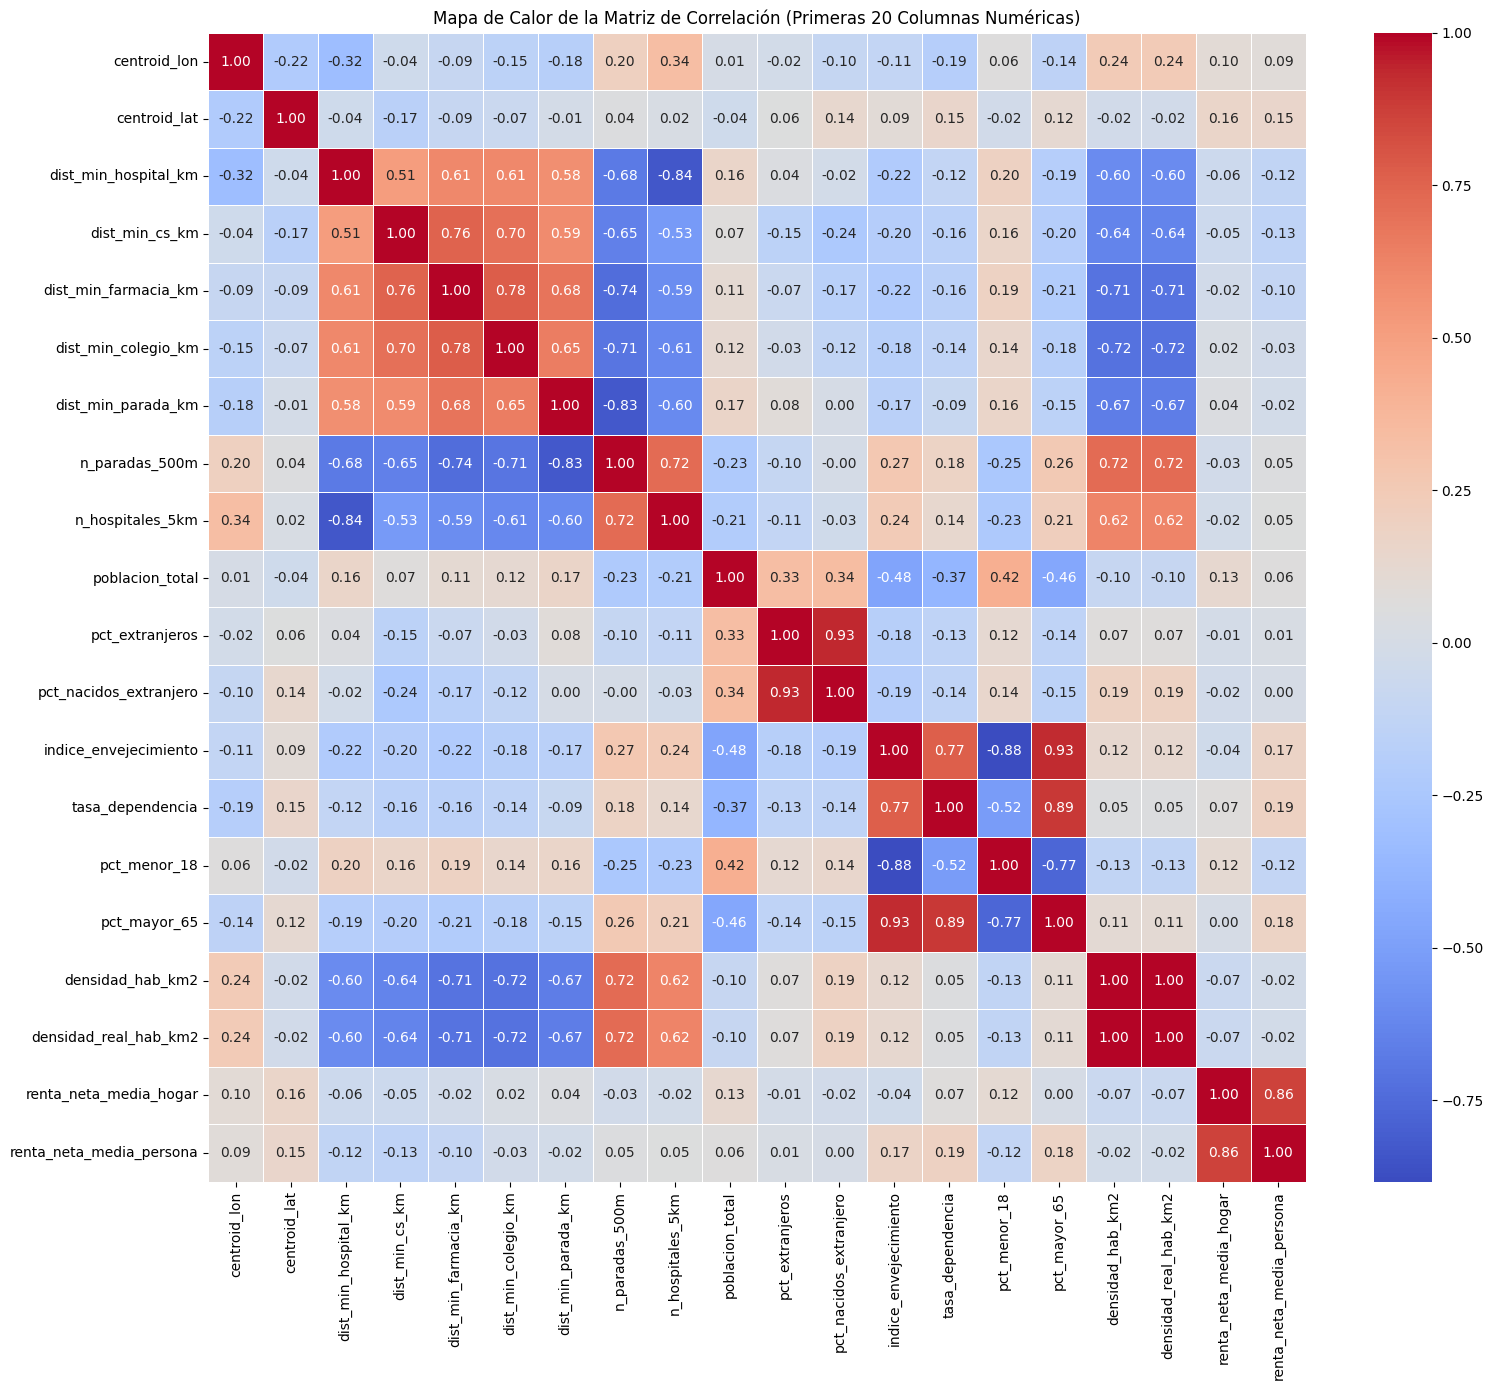

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("--- Calculando matriz de correlación para columnas numéricas ---")

# Seleccionar solo columnas numéricas
numerical_cols_merged = merged_df.select_dtypes(include=np.number)

# Excluir las columnas _log1p para evitar correlaciones directas con las originales
numerical_cols_merged_filtered = numerical_cols_merged.loc[:, ~numerical_cols_merged.columns.str.endswith('_log1p')]

# Calcular la matriz de correlación usando el método de Spearman
correlation_matrix = numerical_cols_merged_filtered.corr(method='spearman')

# --- Identificar pares de columnas altamente correlacionadas (redundancia) ---
correlation_threshold = 0.95

highly_correlated_pairs = []
# Recorrer la mitad superior de la matriz para evitar duplicados y auto-correlación
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) > correlation_threshold:
            highly_correlated_pairs.append((col1, col2, corr_value))

if highly_correlated_pairs:
    print(f"\nSe encontraron {len(highly_correlated_pairs)} pares de columnas con correlación > {correlation_threshold}:")
    for col1, col2, corr_value in highly_correlated_pairs:
        print(f"  - '{col1}' y '{col2}': {corr_value:.4f}")
else:
    print(f"\nNo se encontraron pares de columnas con correlación > {correlation_threshold}.")


# --- Validar correlaciones esperadas (sentido geográfico/socioeconómico) ---
print("\n--- Correlaciones específicas esperadas ---")

specific_correlations = [
    ('renta_neta_media_persona', 'dist_min_hospital_km'),
    ('renta_neta_media_hogar', 'dist_min_hospital_km'),
    ('poblacion_total', 'area_km2'), # Debería ser alta y positiva
    ('poblacion_total', 'densidad_hab_km2')
]

for col1, col2 in specific_correlations:
    if col1 in correlation_matrix.columns and col2 in correlation_matrix.columns:
        corr_value = correlation_matrix.loc[col1, col2]
        print(f"  - Correlación entre '{col1}' y '{col2}': {corr_value:.4f}")
    else:
        print(f"  - Advertencia: Una o ambas columnas ('{col1}', '{col2}') no se encontraron en la matriz de correlación.")


print("\n--- Mapa de calor de la matriz de correlación (primeras 20 columnas) ---")
# Para una visualización más general, mostrar un mapa de calor para las primeras N columnas
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix.iloc[:20, :20], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación (Primeras 20 Columnas Numéricas)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

--- Visualizando distribuciones de columnas sesgadas antes y después de `log1p` ---


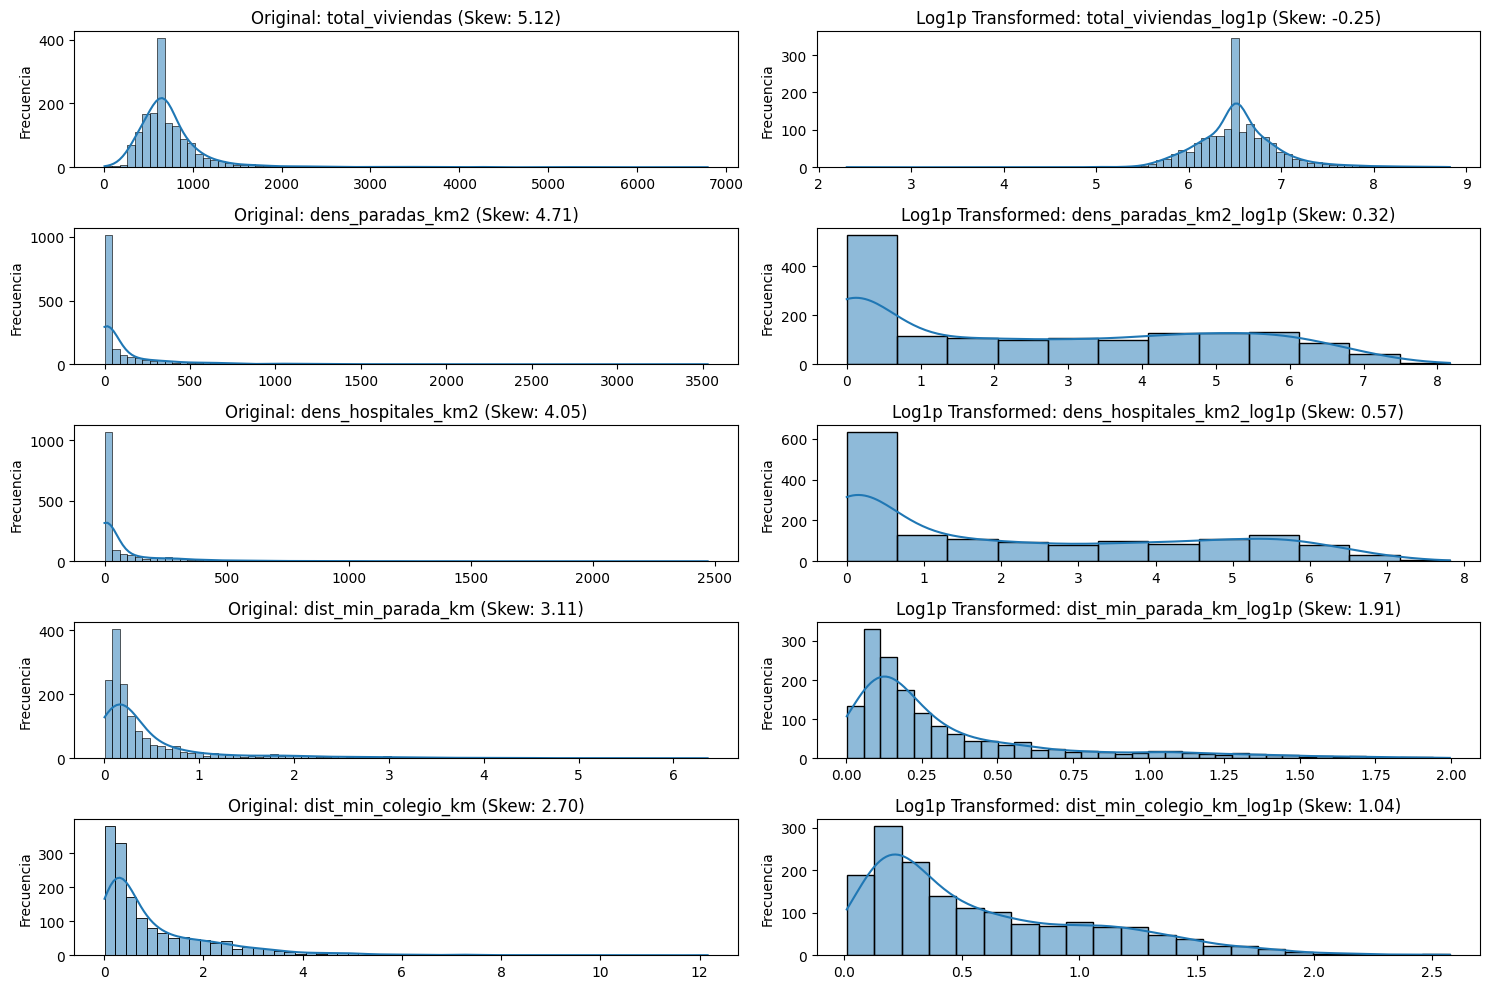

Visualizaciones completadas.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualizando distribuciones de columnas sesgadas antes y después de `log1p` ---")

# Obtener las 5 columnas más sesgadas que fueron transformadas
transformed_cols_to_plot = highly_skewed_cols.head(5).index.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(transformed_cols_to_plot):
    # Subplot para la columna original
    plt.subplot(5, 2, 2*i + 1)
    sns.histplot(merged_df[col].dropna(), kde=True)
    plt.title(f'Original: {col} (Skew: {skew_values_initial[col]:.2f})')
    plt.xlabel('')
    plt.ylabel('Frecuencia')

    # Subplot para la columna transformada
    if (col + '_log1p') in merged_df.columns:
        plt.subplot(5, 2, 2*i + 2)
        sns.histplot(merged_df[col + '_log1p'].dropna(), kde=True)
        new_skew = skew(merged_df[col + '_log1p'].dropna())
        plt.title(f'Log1p Transformed: {col}_log1p (Skew: {new_skew:.2f})')
        plt.xlabel('')
        plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("Visualizaciones completadas.")

In [17]:
print("--- Columnas 'object' (dataset_final 36 cols) ---")
object_cols = merged_df.select_dtypes(include='object').columns.tolist()
print(f"object: {object_cols}")
print("Decisión: 'isla' es la única categórica; NO se aplica OHE (leakage de identidad).")
print("'CUSEC' es identificador. 'nmun' no existe en dataset_final.")
print(f"Shape se mantiene: {merged_df.shape}")


--- Columnas 'object' (dataset_final 36 cols) ---
object: ['CUSEC', 'isla']
Decisión: 'isla' es la única categórica; NO se aplica OHE (leakage de identidad).
'CUSEC' es identificador. 'nmun' no existe en dataset_final.
Shape se mantiene: (1581, 60)


C:\Users\selen\AppData\Local\Temp\ipykernel_23924\2469106039.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = merged_df.select_dtypes(include='object').columns.tolist()


In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler
# Feature set 14 temáticas + 4 KPIs = 18 (canónico, 1 sola densidad para evitar multicolinealidad)
FEATURES_TEMATICAS = {
    'salud':      ['dist_min_hospital_km', 'dist_min_cs_km', 'dist_min_farmacia_km', 'n_hospitales_5km'],
    'transporte': ['dist_min_parada_km', 'n_paradas_500m'],
    'demografia': ['poblacion_total', 'pct_extranjeros', 'indice_envejecimiento',
                   'tasa_dependencia', 'pct_menor_18', 'pct_mayor_65', 'densidad_real_hab_km2'],
    'educacion':  ['dist_min_colegio_km'],
}
FEATURES_NO_ECONOMICAS = []
for dimension, cols in FEATURES_TEMATICAS.items():
    for col in cols:
        log_col = col + '_log1p'
        if log_col in merged_df.columns: FEATURES_NO_ECONOMICAS.append(log_col); print(f'  [{dimension}] {col} -> {log_col}')
        elif col in merged_df.columns: FEATURES_NO_ECONOMICAS.append(col); print(f'  [{dimension}] {col}')
        else: print(f'  [{dimension}] WARN: {col}')
KPIS_VALIDOS = ['estimated_persons_per_household','relative_island_density','relative_island_household_wealth','healthcare_offer_demand_ratio']
for kpi in KPIS_VALIDOS:
    if kpi in merged_df.columns: FEATURES_NO_ECONOMICAS.append(kpi); print(f'  [KPI] {kpi}')
print(f'Total features ({len(FEATURES_NO_ECONOMICAS)}): {FEATURES_NO_ECONOMICAS}')
assert len(FEATURES_NO_ECONOMICAS)==18, FEATURES_NO_ECONOMICAS
assert 'densidad_hab_km2' not in FEATURES_NO_ECONOMICAS and 'densidad_calculada' not in FEATURES_NO_ECONOMICAS, 'duplicidad densidad'
X_raw = merged_df[FEATURES_NO_ECONOMICAS].copy().fillna(median_safe if 'median_safe' in locals() else None) if False else merged_df[FEATURES_NO_ECONOMICAS].copy()
X_raw = X_raw.fillna(X_raw.median())
X_scaled = StandardScaler().fit_transform(X_raw)
print(f'X_scaled shape: {X_scaled.shape}')


  [salud] dist_min_hospital_km -> dist_min_hospital_km_log1p
  [salud] dist_min_cs_km -> dist_min_cs_km_log1p
  [salud] dist_min_farmacia_km -> dist_min_farmacia_km_log1p
  [salud] n_hospitales_5km
  [transporte] dist_min_parada_km -> dist_min_parada_km_log1p
  [transporte] n_paradas_500m -> n_paradas_500m_log1p
  [demografia] poblacion_total -> poblacion_total_log1p
  [demografia] pct_extranjeros -> pct_extranjeros_log1p
  [demografia] indice_envejecimiento -> indice_envejecimiento_log1p
  [demografia] tasa_dependencia
  [demografia] pct_menor_18
  [demografia] pct_mayor_65
  [demografia] densidad_real_hab_km2 -> densidad_real_hab_km2_log1p
  [educacion] dist_min_colegio_km -> dist_min_colegio_km_log1p
  [KPI] estimated_persons_per_household
  [KPI] relative_island_density
  [KPI] relative_island_household_wealth
  [KPI] healthcare_offer_demand_ratio
Total features (18): ['dist_min_hospital_km_log1p', 'dist_min_cs_km_log1p', 'dist_min_farmacia_km_log1p', 'n_hospitales_5km', 'dist_min_

In [19]:
print('--- Verificación de columnas OHE y exclusión de modelos ---\n')

ohe_isla = [col for col in merged_df.columns if col.startswith('isla_')]
ohe_nmun = [col for col in merged_df.columns if col.startswith('nmun_')]
ohe_all  = ohe_isla + ohe_nmun

print(f'Columnas OHE isla:      {len(ohe_isla)}')
print(f'Columnas OHE municipio: {len(ohe_nmun)}')
print(f'Total OHE:              {len(ohe_all)}')
print()
print('[DECISIÓN METODOLÓGICA]')
print('Las columnas OHE de isla y municipio NO se incluyen en el feature set')
print('de ningún modelo (Autoencoder, PCA, K-Means, XGBoost).')
print('Razón: codifican identidad geográfica directa (leakage de identidad).')
print('Permanecen en merged_df solo para análisis descriptivos.')


--- Verificación de columnas OHE y exclusión de modelos ---

Columnas OHE isla:      0
Columnas OHE municipio: 0
Total OHE:              0

[DECISIÓN METODOLÓGICA]
Las columnas OHE de isla y municipio NO se incluyen en el feature set
de ningún modelo (Autoencoder, PCA, K-Means, XGBoost).
Razón: codifican identidad geográfica directa (leakage de identidad).
Permanecen en merged_df solo para análisis descriptivos.


### 11. Distribuciones `_log1p`

--- Distribuciones _log1p (segundo set) ---


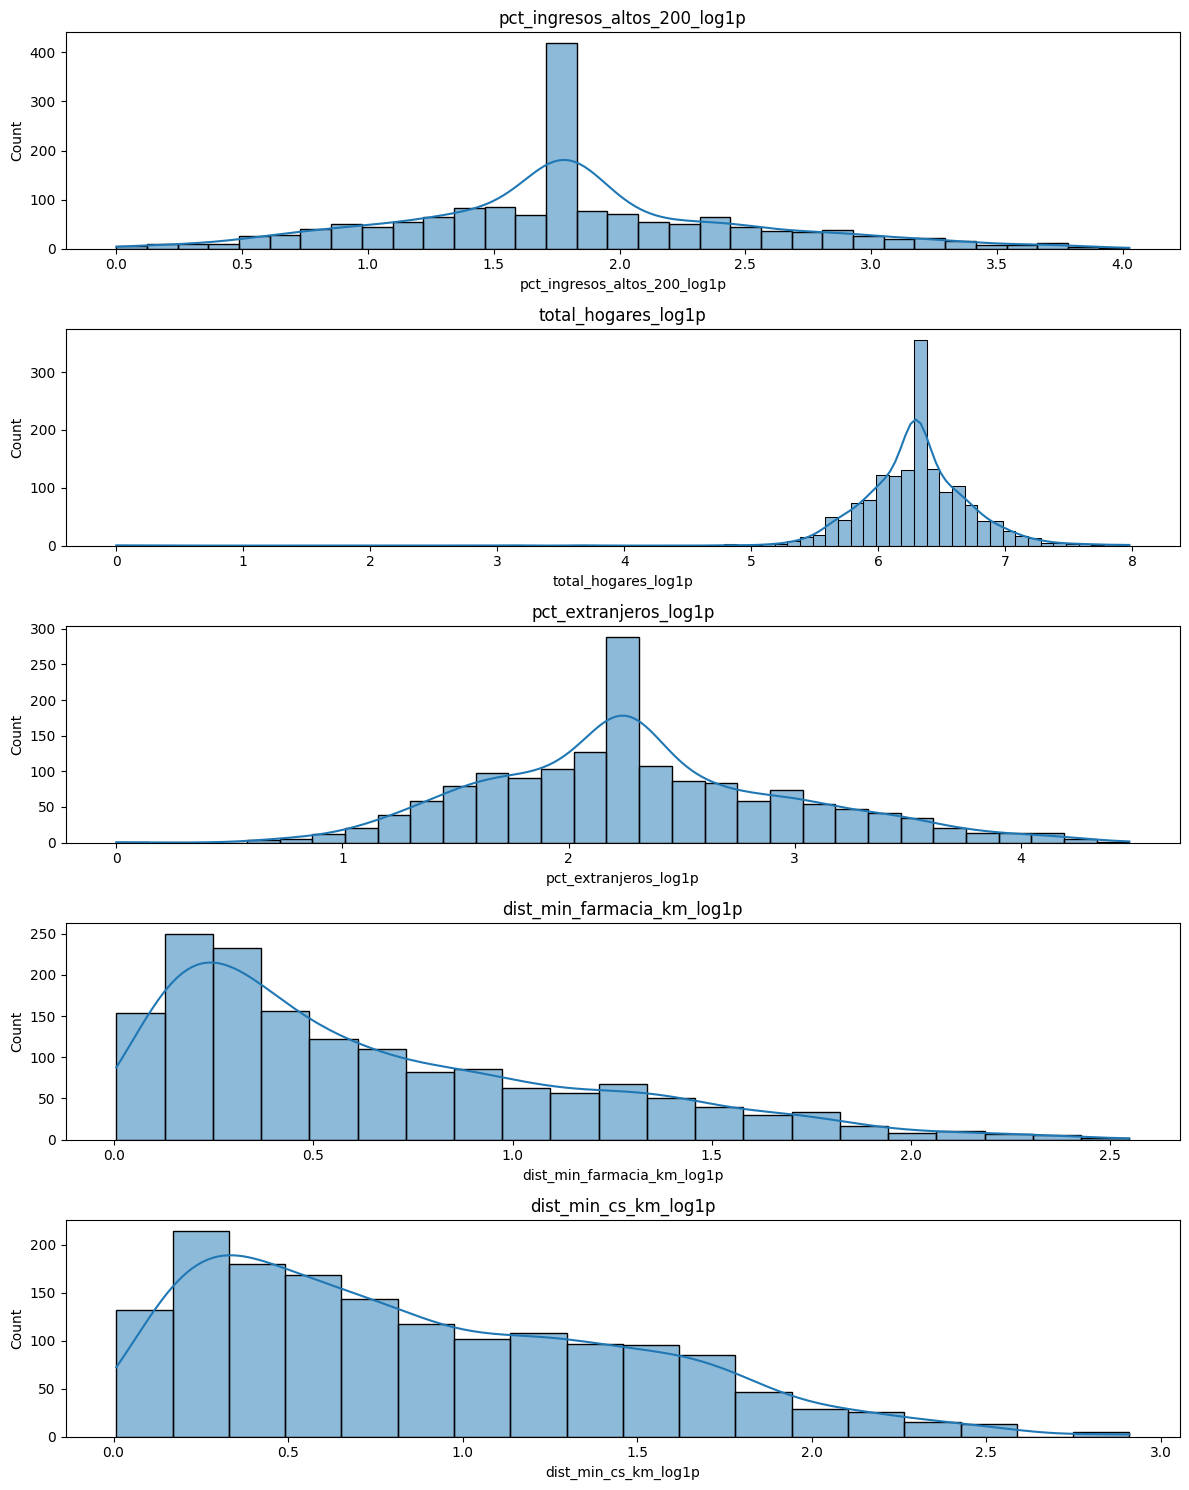

Cierre visual antes del clustering.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
print("--- Distribuciones _log1p (segundo set) ---")
if 'highly_skewed_cols' not in locals():
    print("Ejecuta antes la celda de skew (§10).")
else:
    cols = [f'{c}_log1p' for c in highly_skewed_cols.index.tolist() if f'{c}_log1p' in merged_df.columns][5:10]
    if not cols: print("Sin segundo set de 5.")
    else:
        plt.figure(figsize=(12, len(cols)*3))
        for i, col in enumerate(cols):
            plt.subplot(len(cols),1,i+1); sns.histplot(merged_df[col].dropna(), kde=True)
            plt.title(f'{col}')
        plt.tight_layout(); plt.show()
print("Cierre visual antes del clustering.")


--- Calculando matriz de correlación para columnas _log1p transformadas ---
Se encontraron 20 columnas transformadas con '_log1p'.
Matriz de correlación calculada.


,total_viviendas_log1p,dens_paradas_km2_log1p,dens_hospitales_km2_log1p,dist_min_parada_km_log1p,dist_min_colegio_km_log1p,pct_ingresos_altos_200_log1p,total_hogares_log1p,pct_extranjeros_log1p,dist_min_farmacia_km_log1p,dist_min_cs_km_log1p,renta_neta_media_hogar_log1p,densidad_real_hab_km2_log1p,dist_min_hospital_km_log1p,poblacion_total_log1p,renta_neta_media_persona_log1p,n_paradas_500m_log1p,pct_nacidos_extranjero_log1p,indice_envejecimiento_log1p,pct_ingresos_bajos_7500_log1p,pct_estudios_superiores_log1p
total_viviendas_log1p,1.000000,-0.276341,-0.277157,0.191340,0.167635,0.180109,0.921049,0.356332,0.119554,0.086314,0.110510,-0.167316,0.162082,0.843198,0.192023,-0.234607,0.346336,-0.275773,0.055890,0.177982
dens_paradas_km2_log1p,-0.276341,1.000000,0.848111,-0.821742,-0.767945,-0.019848,-0.163232,-0.050367,-0.780197,-0.690166,-0.056584,0.850284,-0.681403,-0.253107,0.018201,0.932125,0.053500,0.248747,0.165267,0.134111
dens_hospitales_km2_log1p,-0.277157,0.848111,1.000000,-0.681239,-0.699776,-0.011958,-0.167177,-0.089566,-0.681163,-0.602689,-0.034108,0.759724,-0.847979,-0.255829,0.038796,0.781639,0.001532,0.243608,0.126818,0.139707
dist_min_parada_km_log1p,0.191340,-0.821742,-0.681239,1.000000,0.650715,-0.003604,0.102063,0.081644,0.684349,0.594868,0.037658,-0.665374,0.579980,0.167222,-0.021018,-0.830109,0.001760,-0.167954,-0.115395,-0.127179
dist_min_colegio_km_log1p,0.167635,-0.767945,-0.699776,0.650715,1.000000,-0.008397,0.052454,-0.028852,0.777786,0.701899,0.020910,-0.716601,0.606060,0.123638,-0.029314,-0.706906,-0.121182,-0.179893,-0.174957,-0.118391



No se encontraron pares de columnas _log1p con correlación > 0.95.

--- Correlaciones específicas esperadas en datos _log1p ---
  - Correlación entre 'renta_neta_media_persona_log1p' y 'dist_min_hospital_km_log1p': -0.1202
  - Correlación entre 'renta_neta_media_hogar_log1p' y 'dist_min_hospital_km_log1p': -0.0585
  - Advertencia: Una o ambas columnas ('poblacion_total_log1p', 'area_km2_log1p') no se encontraron en la matriz de correlación _log1p.
  - Advertencia: Una o ambas columnas ('poblacion_total_log1p', 'densidad_hab_km2_log1p') no se encontraron en la matriz de correlación _log1p.

--- Mapa de calor de la matriz de correlación (primeras 20 columnas _log1p) ---


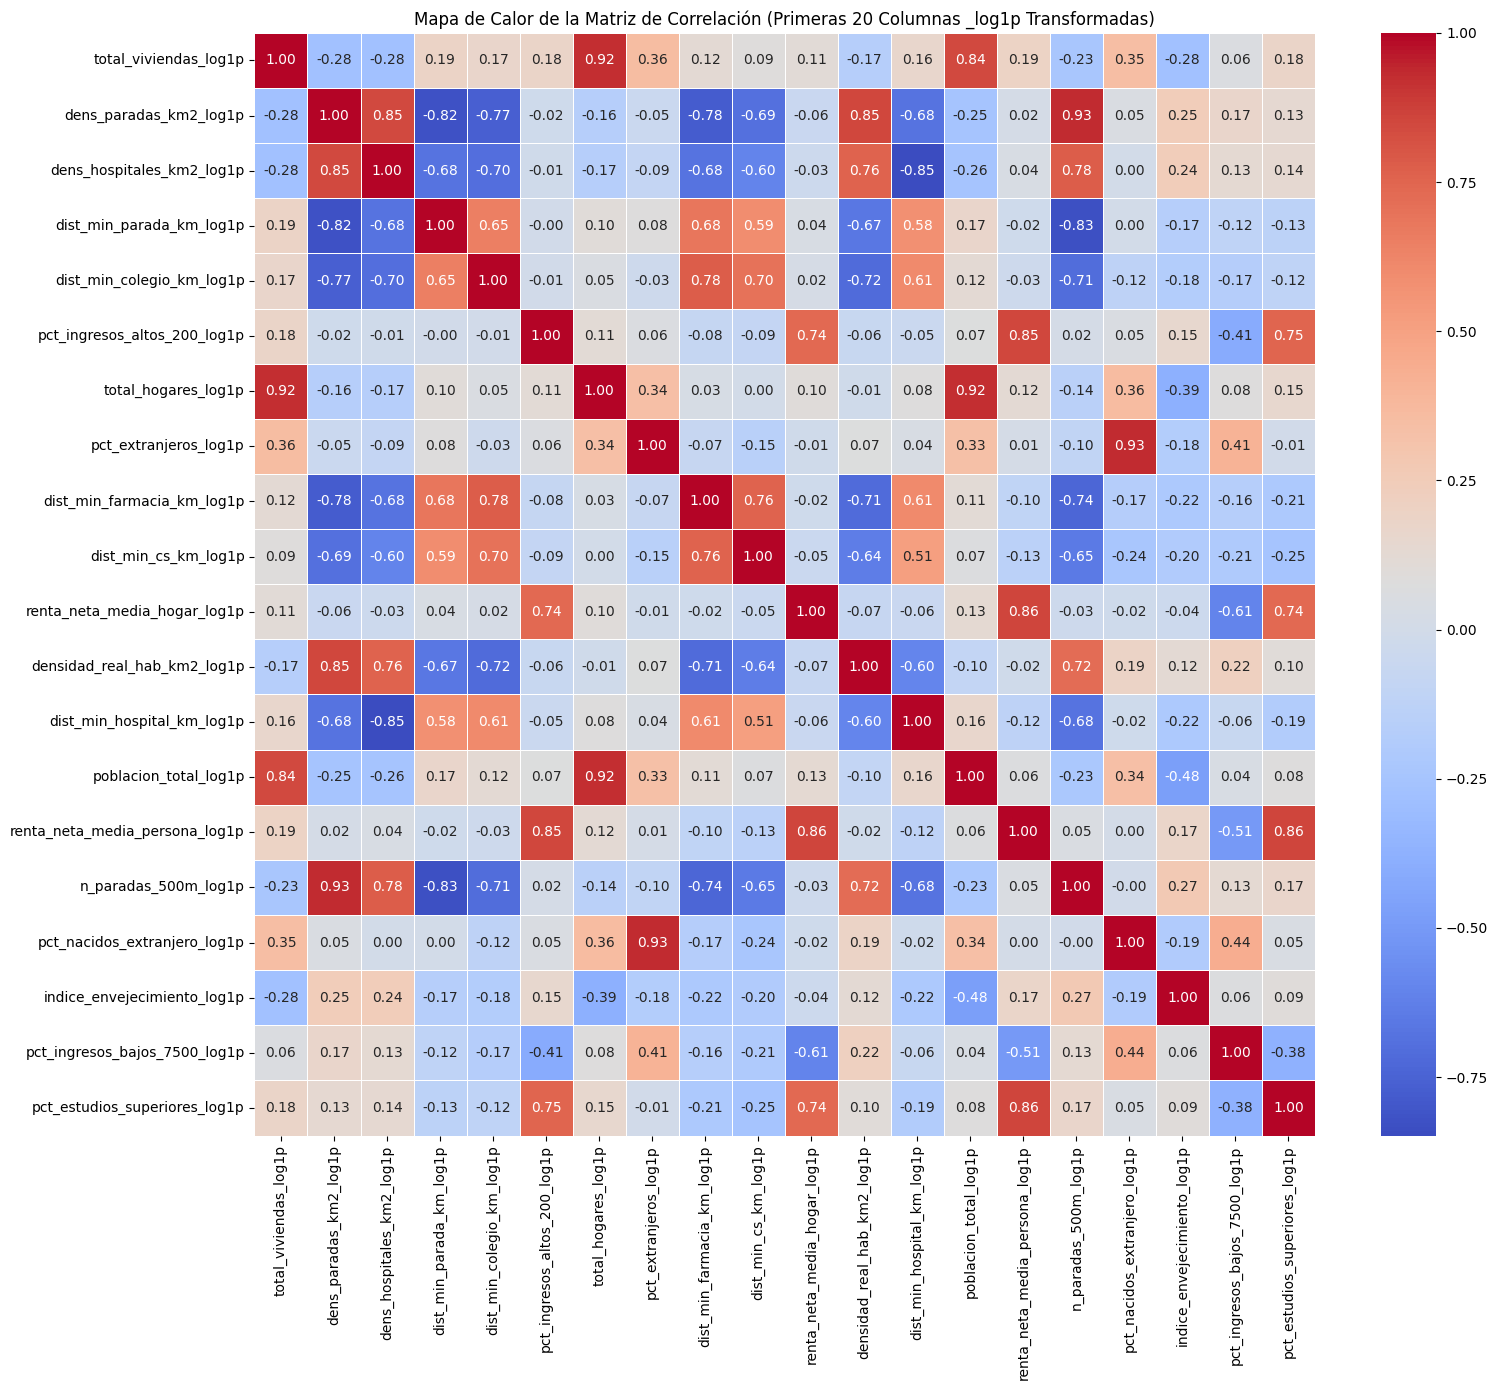

Análisis de correlación de columnas _log1p completado.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- Calculando matriz de correlación para columnas _log1p transformadas ---")

# Seleccionar solo columnas que terminan con '_log1p'
log1p_cols = [col for col in merged_df.columns if col.endswith('_log1p')]

if not log1p_cols:
    print("No se encontraron columnas transformadas con '_log1p'.")
else:
    print(f"Se encontraron {len(log1p_cols)} columnas transformadas con '_log1p'.")

    # Crear un DataFrame solo con estas columnas
    log1p_df = merged_df[log1p_cols].copy()

    # Calcular la matriz de correlación usando el método de Spearman
    correlation_matrix_log1p = log1p_df.corr(method='spearman')

    print("Matriz de correlación calculada.")
    display(correlation_matrix_log1p.head())

    # --- Identificar pares de columnas altamente correlacionadas (redundancia) ---
    correlation_threshold = 0.95

    highly_correlated_pairs_log1p = []
    # Recorrer la mitad superior de la matriz para evitar duplicados y auto-correlación
    for i in range(len(correlation_matrix_log1p.columns)):
        for j in range(i + 1, len(correlation_matrix_log1p.columns)):
            col1 = correlation_matrix_log1p.columns[i]
            col2 = correlation_matrix_log1p.columns[j]
            corr_value = correlation_matrix_log1p.iloc[i, j]

            if abs(corr_value) > correlation_threshold:
                highly_correlated_pairs_log1p.append((col1, col2, corr_value))

    if highly_correlated_pairs_log1p:
        print(f"\nSe encontraron {len(highly_correlated_pairs_log1p)} pares de columnas _log1p con correlación > {correlation_threshold}:")
        for col1, col2, corr_value in highly_correlated_pairs_log1p:
            print(f"  - '{col1}' y '{col2}': {corr_value:.4f}")
    else:
        print(f"\nNo se encontraron pares de columnas _log1p con correlación > {correlation_threshold}.")

    # --- Validar correlaciones específicas esperadas en datos _log1p ---
    specific_correlations_log1p = [
        ('renta_neta_media_persona_log1p', 'dist_min_hospital_km_log1p'),
        ('renta_neta_media_hogar_log1p', 'dist_min_hospital_km_log1p'),
        ('poblacion_total_log1p', 'area_km2_log1p'),
        ('poblacion_total_log1p', 'densidad_hab_km2_log1p')
    ]

    print("\n--- Correlaciones específicas esperadas en datos _log1p ---")
    for col1, col2 in specific_correlations_log1p:
        if col1 in correlation_matrix_log1p.columns and col2 in correlation_matrix_log1p.columns:
            corr_value = correlation_matrix_log1p.loc[col1, col2]
            print(f"  - Correlación entre '{col1}' y '{col2}': {corr_value:.4f}")
        else:
            print(f"  - Advertencia: Una o ambas columnas ('{col1}', '{col2}') no se encontraron en la matriz de correlación _log1p.")


    print("\n--- Mapa de calor de la matriz de correlación (primeras 20 columnas _log1p) ---")
    plt.figure(figsize=(16, 14))
    sns.heatmap(correlation_matrix_log1p.iloc[:20, :20], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Mapa de Calor de la Matriz de Correlación (Primeras 20 Columnas _log1p Transformadas)')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("Análisis de correlación de columnas _log1p completado.")

In [22]:
import folium
import pandas as pd
import numpy as np
print("--- Mapa CUSECs por isla (dataset_final, centroid_lon/lat) ---")
isla_colors = {'Gran Canaria':'blue','Tenerife':'red','La Palma':'green','Fuerteventura':'orange','Lanzarote':'purple','La Gomera':'darkgreen','El Hierro':'cadetblue'}
dfm = merged_df.dropna(subset=['centroid_lon','centroid_lat']).copy()
center = [dfm['centroid_lat'].mean(), dfm['centroid_lon'].mean()]
m = folium.Map(location=center, zoom_start=8)
for _, r in dfm.sample(min(500, len(dfm))).iterrows():
    folium.CircleMarker([r['centroid_lat'], r['centroid_lon']], radius=2,
        color=isla_colors.get(r['isla'],'gray'), fill=True, fill_opacity=0.6,
        popup=f"{r['CUSEC']} {r['isla']}").add_to(m)
display(m)
print(f"Mostradas {min(500,len(dfm))}/{len(dfm)} secciones (muestra para rendimiento). Para coropletas usar dataset_final.gpkg en QGIS/geopandas).")


--- Mapa CUSECs por isla (dataset_final, centroid_lon/lat) ---


Mostradas 500/1581 secciones (muestra para rendimiento). Para coropletas usar dataset_final.gpkg en QGIS/geopandas).


In [23]:
# Mapa post-merge unificado en celda anterior (centroid_lon/lat canónicos).
# Sin _x/_y: dataset_final no hace merge. Ver dataset_final.gpkg para geometría completa (EPSG:32628).
print("OK: mapa único válido (celda anterior).")


OK: mapa único válido (celda anterior).


### 12. Correlación en espacio `_log1p` y conteo

Spearman sobre `*_log1p` replica la estructura del original. 

In [24]:
print("--- Determinando el número de columnas originales y transformadas ---")

# Asegurarse de que merged_df está disponible
if 'merged_df' not in locals():
    raise RuntimeError("'merged_df' no encontrado. Por favor, asegúrese de que las celdas de carga y preprocesamiento de datos se hayan ejecutado.")

# Initialize counters
transformed_log1p_cols_count = 0
original_untransformed_cols_count = 0
original_transformed_base_cols_count = 0

# Keep track of original column names that correspond to a _log1p version
original_cols_with_log1p_version = set()

for col in merged_df.columns:
    if col.endswith('_log1p'):
        transformed_log1p_cols_count += 1
        original_name = col.replace('_log1p', '')
        if original_name in merged_df.columns:
            original_cols_with_log1p_version.add(original_name)

# Now iterate again to count truly untransformed originals
for col in merged_df.columns:
    if not col.endswith('_log1p'): # It's not a _log1p column itself
        if col not in original_cols_with_log1p_version: # And it's not the original for a _log1p column
            # This means it's an original column that was never transformed
            original_untransformed_cols_count += 1

original_transformed_base_cols_count = len(original_cols_with_log1p_version)

# Total original columns in a broad sense (those that are not _log1p versions)
# This is the sum of originals that *were* transformed and originals that *were not* transformed
total_original_cols_in_df = original_transformed_base_cols_count + original_untransformed_cols_count

print(f"Número total de columnas transformadas con '_log1p' (columnas nuevas): {transformed_log1p_cols_count}")
print(f"Número de columnas originales para las que se creó una versión '_log1p': {original_transformed_base_cols_count}")
print(f"Número de columnas originales que NO fueron transformadas con '_log1p': {original_untransformed_cols_count}")
print(f"Número total de columnas base (originales + originales con versión '_log1p'): {total_original_cols_in_df}")
print(f"Verificación: Total de columnas en merged_df: {merged_df.shape[1]}")
print(f"Verificación: Suma de (columnas transformadas) + (columnas base no transformadas): {transformed_log1p_cols_count + original_untransformed_cols_count + original_transformed_base_cols_count}")

print("--- Conteo de columnas completado ---")

--- Determinando el número de columnas originales y transformadas ---
Número total de columnas transformadas con '_log1p' (columnas nuevas): 20
Número de columnas originales para las que se creó una versión '_log1p': 20
Número de columnas originales que NO fueron transformadas con '_log1p': 20
Número total de columnas base (originales + originales con versión '_log1p'): 40
Verificación: Total de columnas en merged_df: 60
Verificación: Suma de (columnas transformadas) + (columnas base no transformadas): 60
--- Conteo de columnas completado ---


In [25]:
# ── K-Means usa X_scaled definido en celda 43 (feature set homogéneo de 18 variables)
# No se prepara un X_scaled propio: garantiza comparabilidad con AE y PCA.
import numpy as np
from sklearn.preprocessing import StandardScaler

print('--- Preparando datos para Clustering K-Means ---')
print(f'Usando X_scaled compartido: shape={X_scaled.shape}')
print(f'Features ({len(FEATURES_NO_ECONOMICAS)}): {FEATURES_NO_ECONOMICAS}')

# X_scaled_kmeans apunta al mismo array que usan AE y PCA
X_scaled_kmeans = X_scaled.copy()
print('\nDatos listos para K-Means (mismo feature set que AE y PCA).')


--- Preparando datos para Clustering K-Means ---
Usando X_scaled compartido: shape=(1581, 18)
Features (18): ['dist_min_hospital_km_log1p', 'dist_min_cs_km_log1p', 'dist_min_farmacia_km_log1p', 'n_hospitales_5km', 'dist_min_parada_km_log1p', 'n_paradas_500m_log1p', 'poblacion_total_log1p', 'pct_extranjeros_log1p', 'indice_envejecimiento_log1p', 'tasa_dependencia', 'pct_menor_18', 'pct_mayor_65', 'densidad_real_hab_km2_log1p', 'dist_min_colegio_km_log1p', 'estimated_persons_per_household', 'relative_island_density', 'relative_island_household_wealth', 'healthcare_offer_demand_ratio']

Datos listos para K-Means (mismo feature set que AE y PCA).


### 13. Clustering K-Means exploratorio (hipótesis de tipologías)

--- Aplicando Método del Codo ---


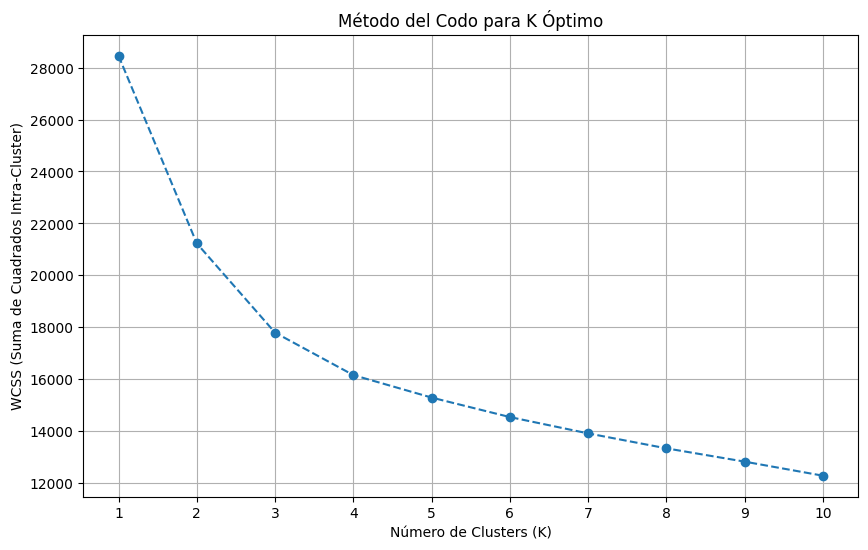

Identifica el 'codo' en el gráfico para estimar el número óptimo de clusters.


In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("--- Aplicando Método del Codo ---")

wcss = []
max_k = 10 # Se puede ajustar según el tamaño del dataset y la lógica de negocio

if 'X_scaled' in locals():
    for i in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init para evitar warnings
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
    plt.title('Método del Codo para K Óptimo')
    plt.xlabel('Número de Clusters (K)')
    plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()

    print("Identifica el 'codo' en el gráfico para estimar el número óptimo de clusters.")
else:
    print("Error: 'X_scaled' no está definido. Asegúrate de que la celda de preparación de datos se haya ejecutado correctamente.")

--- Selección de K: Silhouette Score + Davies-Bouldin Index ---
  K= 2  |  Silhouette=0.2372  |  Davies-Bouldin=1.5407
  K= 3  |  Silhouette=0.2057  |  Davies-Bouldin=1.6075
  K= 4  |  Silhouette=0.1816  |  Davies-Bouldin=1.7019
  K= 5  |  Silhouette=0.1599  |  Davies-Bouldin=1.8691
  K= 6  |  Silhouette=0.1621  |  Davies-Bouldin=1.8078
  K= 7  |  Silhouette=0.1589  |  Davies-Bouldin=1.7416
  K= 8  |  Silhouette=0.1345  |  Davies-Bouldin=1.8155
  K= 9  |  Silhouette=0.1373  |  Davies-Bouldin=1.7686
  K=10  |  Silhouette=0.1376  |  Davies-Bouldin=1.6149

--- Tabla resumen (Silhouette: mayor=mejor | Davies-Bouldin: menor=mejor) ---


,K,Silhouette,Davies-Bouldin
0,2,0.237181,1.540689
1,3,0.205656,1.607498
2,4,0.181574,1.701917
3,5,0.159888,1.869135
4,6,0.162115,1.807784
5,7,0.158857,1.741582
6,8,0.134518,1.815524
7,9,0.137346,1.768631
8,10,0.137627,1.614870


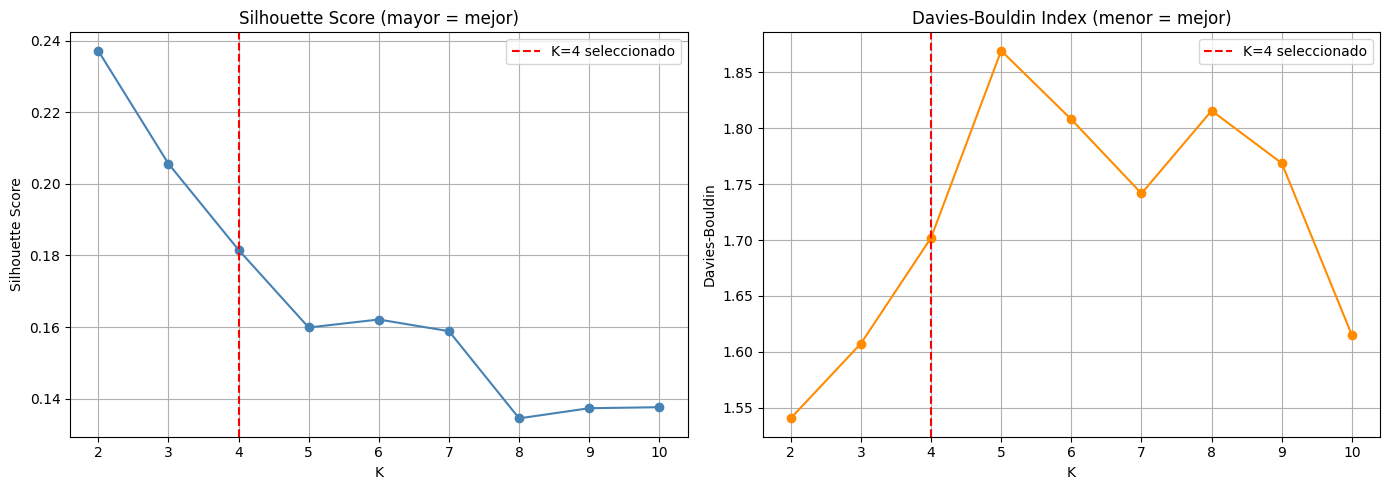


  K óptimo por Silhouette:     K=2
  K óptimo por Davies-Bouldin: K=2

[DECISIÓN METODOLÓGICA — K=4]
Ningún índice cuantitativo señala K=4 como óptimo:
  - Silhouette máximo: K=2
  - Davies-Bouldin mínimo: K=2

La elección de K=4 se justifica exclusivamente por criterios territoriales:
  1. K=2 y K=3 colapsan perfiles territorialmente distintos en un único cluster
     (islas menores + periferias vulnerables de islas capitalinas).
  2. K=5 produce clusters con < 10 secciones en islas menores (El Hierro,
     La Gomera), insuficientes para interpretación estadística fiable.
  3. K=4 reproduce los cuatro perfiles identificados en la literatura de
     tipologías socioterritoriales insulares (OCDE, 2008; Eurostat, 2018):
     núcleo urbano, periurbano conectado, rural envejecido y periferia aislada.

Esta justificación territorial debe documentarse explícitamente en la memoria.


⚠ ANOTAR PARA EL DOCUMENTO:
  K=2:  Silhouette=0.2372  |  DB=1.5407
  K=3:  Silhouette=0.2057  |  DB=1.6075
 

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import pandas as pd

print('--- Selección de K: Silhouette Score + Davies-Bouldin Index ---')

max_k = 10
silhouette_scores = []
davies_bouldin_scores = []
k_range = range(2, max_k + 1)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    silhouette_scores.append(sil)
    davies_bouldin_scores.append(db)
    print(f'  K={k:2d}  |  Silhouette={sil:.4f}  |  Davies-Bouldin={db:.4f}')

results_df = pd.DataFrame({
    'K': list(k_range),
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores
})
print('\n--- Tabla resumen (Silhouette: mayor=mejor | Davies-Bouldin: menor=mejor) ---')
display(results_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(k_range), silhouette_scores, marker='o', color='steelblue')
ax1.axvline(x=4, color='red', linestyle='--', label='K=4 seleccionado')
ax1.set_title('Silhouette Score (mayor = mejor)')
ax1.set_xlabel('K'); ax1.set_ylabel('Silhouette Score')
ax1.legend(); ax1.grid(True)

ax2.plot(list(k_range), davies_bouldin_scores, marker='o', color='darkorange')
ax2.axvline(x=4, color='red', linestyle='--', label='K=4 seleccionado')
ax2.set_title('Davies-Bouldin Index (menor = mejor)')
ax2.set_xlabel('K'); ax2.set_ylabel('Davies-Bouldin')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

k_sil_opt = results_df.loc[results_df['Silhouette'].idxmax(), 'K']
k_db_opt  = results_df.loc[results_df['Davies-Bouldin'].idxmin(), 'K']
print(f'\n  K óptimo por Silhouette:     K={k_sil_opt}')
print(f'  K óptimo por Davies-Bouldin: K={k_db_opt}')

print('''
[DECISIÓN METODOLÓGICA — K=4]
Ningún índice cuantitativo señala K=4 como óptimo:
  - Silhouette máximo: K=2
  - Davies-Bouldin mínimo: K=2

La elección de K=4 se justifica exclusivamente por criterios territoriales:
  1. K=2 y K=3 colapsan perfiles territorialmente distintos en un único cluster
     (islas menores + periferias vulnerables de islas capitalinas).
  2. K=5 produce clusters con < 10 secciones en islas menores (El Hierro,
     La Gomera), insuficientes para interpretación estadística fiable.
  3. K=4 reproduce los cuatro perfiles identificados en la literatura de
     tipologías socioterritoriales insulares (OCDE, 2008; Eurostat, 2018):
     núcleo urbano, periurbano conectado, rural envejecido y periferia aislada.

Esta justificación territorial debe documentarse explícitamente en la memoria.
''')

print('\n⚠ ANOTAR PARA EL DOCUMENTO:')
for _, row in results_df[results_df['K'].isin([2, 3, 4, 5])].iterrows():
    print(f'  K={int(row["K"])}:  Silhouette={row["Silhouette"]:.4f}  |  DB={row["Davies-Bouldin"]:.4f}')

optimal_k = 4
print(f'\noptimal_k = {optimal_k} (fijado por criterio territorial)')

--- Aplicando K-Means con K = 4 ---
K-Means completado con 4 clusters.

--- Distribución de Clústeres por Isla ---


cluster_label,0,1,2,3
isla,,,,
El Hierro,0,0,8,1
Fuerteventura,33,0,32,2
Gran Canaria,113,232,82,215
La Gomera,1,0,18,4
La Palma,5,9,42,27
Lanzarote,47,1,24,15
Tenerife,130,212,106,222



--- Visualización de la Distribución de Clústeres por Isla ---


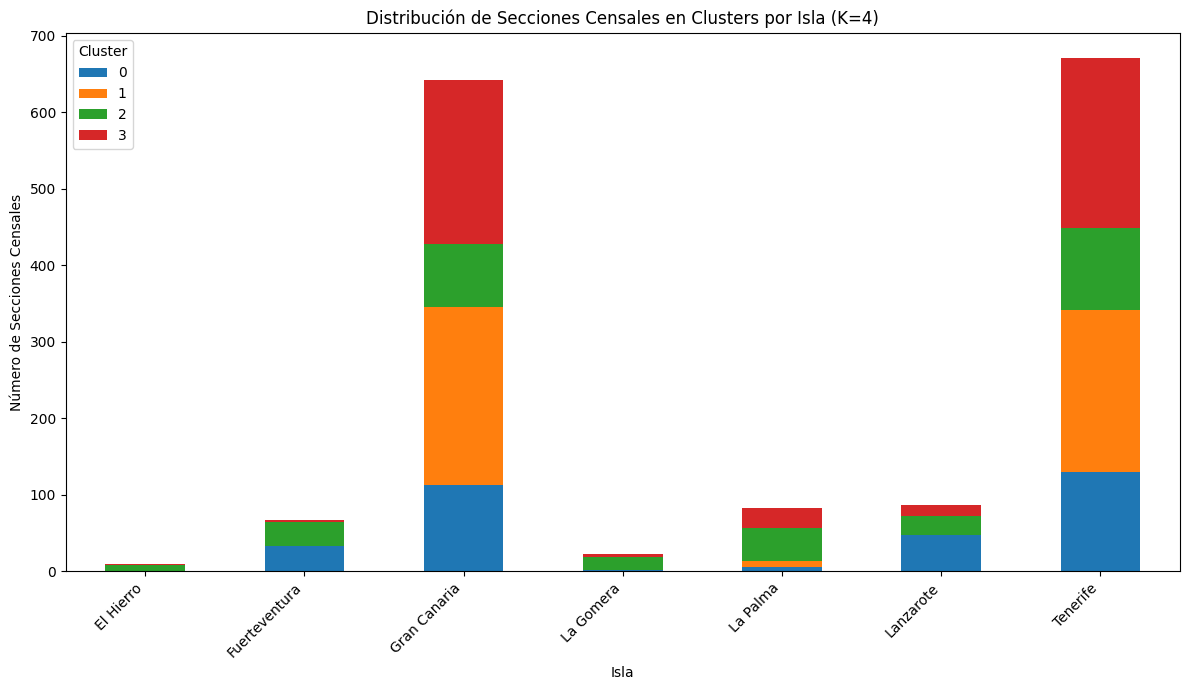


--- Estadísticas Descriptivas de los Clústeres ---


,poblacion_total,renta_neta_media_hogar,tasa_dependencia
cluster_label,,,
0,2180.832827,35602.146505,36.681385
1,1291.592511,37661.931608,50.098690
2,1576.314103,34436.240032,46.107270
3,1487.765432,36466.984177,45.893692


El análisis de estas estadísticas y la distribución por isla permite interpretar las tipologías territoriales emergentes.


In [28]:
optimal_k = 4 # @param {type:"integer"}

print(f"--- Aplicando K-Means con K = {optimal_k} ---")

if 'X_scaled' in locals():
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    merged_df['cluster_label'] = kmeans.fit_predict(X_scaled)

    print(f"K-Means completado con {optimal_k} clusters.")

    print("\n--- Distribución de Clústeres por Isla ---")
    # Asegurarse de que 'isla' no tiene nulos para este análisis o imputarlos si es necesario
    cluster_distribution = merged_df.groupby(['isla', 'cluster_label']).size().unstack(fill_value=0)
    display(cluster_distribution)

    print("\n--- Visualización de la Distribución de Clústeres por Isla ---")
    cluster_distribution.plot(kind='bar', stacked=True, figsize=(12, 7))
    plt.title(f'Distribución de Secciones Censales en Clusters por Isla (K={optimal_k})')
    plt.xlabel('Isla')
    plt.ylabel('Número de Secciones Censales')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

    print("\n--- Estadísticas Descriptivas de los Clústeres ---")
    # Para entender mejor cada cluster, podemos ver las estadísticas de las características originales
    # o las transformadas para cada cluster. Usaremos un subconjunto relevante de features.
    # Se han eliminado las características que no estaban presentes en el `merged_df` debido a la recarga previa del DataFrame
    # en la celda `5sxJPckFb_YA`, ya que no fueron guardadas en el CSV y se perdieron.
    relevant_features_for_description = ['poblacion_total', 'renta_neta_media_hogar',
                                         'tasa_dependencia']

    cluster_summary = merged_df.groupby('cluster_label')[relevant_features_for_description].mean()
    display(cluster_summary)

    print("El análisis de estas estadísticas y la distribución por isla permite interpretar las tipologías territoriales emergentes.")
else:
    print("Error: 'X_scaled' no está definido. Asegúrate de que la celda de preparación de datos se haya ejecutado correctamente.")

### 14. Perfiles medios por cluster (18 features de clustering)

In [29]:
print("--- Calculando el perfil de las características medias para cada clúster ---")

# Asegurarse de que merged_df está cargado y tiene 'cluster_label'
if 'merged_df' not in locals():
    raise RuntimeError("'merged_df' no está disponible. Asegúrate de ejecutar las celdas de carga de datos.")

if 'cluster_label' not in merged_df.columns:
    raise RuntimeError("'cluster_label' no encontrado en 'merged_df'. Asegúrate de que K-Means se ha ejecutado.")

# Define clustering_features_df using X_raw (which contains the features used for clustering)
# X_raw is created in cell 'V4dwonW3-4HU' from FEATURES_NO_ECONOMICAS.
# Ensure its index aligns with merged_df for proper concatenation later.
if 'X_raw' in locals() and isinstance(X_raw, pd.DataFrame):
    clustering_features_df = X_raw.copy()
    # Ensure the index is aligned for concatenation, assuming X_raw was built from merged_df
    # If merged_df index is CUSEC, and X_raw has a default integer index, reset X_raw's index to CUSEC
    if merged_df.index.name == 'CUSEC' and 'CUSEC' in merged_df.columns and X_raw.index.name != 'CUSEC':
        # This assumes X_raw rows correspond to merged_df rows, which they should if created sequentially.
        # Re-indexing X_raw to match merged_df's CUSEC index for a robust join.
        clustering_features_df.index = merged_df.index # Align indices
else:
    raise RuntimeError("'X_raw' no está disponible o no es un DataFrame. Asegúrate de que la celda de preparación de datos para clustering se ha ejecutado correctamente.")

# Asegurarse de que clustering_features_df está disponible y no está vacío
if clustering_features_df.empty:
    raise RuntimeError("'clustering_features_df' está vacío después de su creación. Revisa la fuente de datos.")

# Combinar las características de clustering con las etiquetas de clúster.
# Se realiza una unión por índice (asumiendo que tanto clustering_features_df como merged_df están indexados por CUSEC)
# Given that merged_df already has the 'cluster_label' column and clustering_features_df is derived from merged_df,
# we can simply select the relevant columns from merged_df.
cluster_profile_data = merged_df[clustering_features_df.columns.tolist() + ['cluster_label']].copy()

# Calcular la media de cada característica por clúster
cluster_summary = cluster_profile_data.groupby('cluster_label').mean()

print("Perfil de características medias por clúster (basado en características de clustering):")
display(cluster_summary)

print("\n--- Distribución de Clústeres por Isla (Conteo) ---")
# Se utiliza merged_df para la distribución por isla, ya que contiene 'isla'
cluster_distribution_by_isla = merged_df.groupby(['isla', 'cluster_label']).size().unstack(fill_value=0)
display(cluster_distribution_by_isla)

print("\nInterpretación:")
print("Para interpretar cada clúster, compare los valores medios de las características con el promedio general de los datos. Por ejemplo:")
print("- **Población/Densidad:** Clústeres con valores altos podrían representar zonas urbanas/densas.")
print("- **Renta:** Clústeres con alta 'renta_neta_media_hogar_log1p' o 'renta_neta_media_persona_log1p' indican mayor riqueza.")
print("- **Accesibilidad/Distancias:** Valores bajos en 'dist_min_hospital_km' o altos en 'n_paradas_500m' sugieren buena accesibilidad.")
print("- **Demografía:** 'pct_extranjeros', 'indice_envejecimiento' y 'tasa_dependencia' revelan el tipo de población.")
print("Analice también la distribución de los clústeres entre las diferentes islas para identificar patrones geográficos.")

--- Calculando el perfil de las características medias para cada clúster ---
Perfil de características medias por clúster (basado en características de clustering):


,dist_min_hospital_km_log1p,dist_min_cs_km_log1p,dist_min_farmacia_km_log1p,n_hospitales_5km,dist_min_parada_km_log1p,n_paradas_500m_log1p,poblacion_total_log1p,pct_extranjeros_log1p,indice_envejecimiento_log1p,tasa_dependencia,pct_menor_18,pct_mayor_65,densidad_real_hab_km2_log1p,dist_min_colegio_km_log1p,estimated_persons_per_household,relative_island_density,relative_island_household_wealth,healthcare_offer_demand_ratio
cluster_label,,,,,,,,,,,,,,,,,,
0,1.208185,0.834781,0.589098,3.720365,0.270005,1.595872,7.624421,2.762103,4.436593,36.681385,17.267660,12.052401,8.303062,0.497036,2.800230,1.068063,0.978791,0.008969
1,0.454118,0.379932,0.236809,14.905286,0.106498,3.003099,7.094101,2.280073,5.391672,50.098690,12.383480,22.584097,9.617288,0.202427,2.566768,2.132496,1.041047,0.041506
2,1.997445,1.626116,1.435668,0.746795,0.910651,0.134940,7.297753,2.407037,5.167275,46.107270,13.500321,19.780545,5.656453,1.300869,2.672090,0.255788,0.951949,0.003735
3,1.300030,0.908862,0.597714,2.915638,0.237516,1.712797,7.255906,1.978273,5.146106,45.893692,13.834012,19.387613,7.493204,0.561941,2.726240,0.373762,1.006861,0.008759



--- Distribución de Clústeres por Isla (Conteo) ---


cluster_label,0,1,2,3
isla,,,,
El Hierro,0,0,8,1
Fuerteventura,33,0,32,2
Gran Canaria,113,232,82,215
La Gomera,1,0,18,4
La Palma,5,9,42,27
Lanzarote,47,1,24,15
Tenerife,130,212,106,222



Interpretación:
Para interpretar cada clúster, compare los valores medios de las características con el promedio general de los datos. Por ejemplo:
- **Población/Densidad:** Clústeres con valores altos podrían representar zonas urbanas/densas.
- **Renta:** Clústeres con alta 'renta_neta_media_hogar_log1p' o 'renta_neta_media_persona_log1p' indican mayor riqueza.
- **Accesibilidad/Distancias:** Valores bajos en 'dist_min_hospital_km' o altos en 'n_paradas_500m' sugieren buena accesibilidad.
- **Demografía:** 'pct_extranjeros', 'indice_envejecimiento' y 'tasa_dependencia' revelan el tipo de población.
Analice también la distribución de los clústeres entre las diferentes islas para identificar patrones geográficos.


In [30]:
print("--- Nombres descriptivos (provisionales PG1/PG2) ---")
cluster_name_mapping = {0:'Zonas Rurales/Baja Densidad',1:'Áreas Urbanas/Densas',2:'Núcleos Densos',3:'Periferia Aislada'}
merged_df['cluster_name'] = merged_df['cluster_label'].map(cluster_name_mapping)
print("Columna 'cluster_name' añadida.")
display(merged_df.groupby(['isla','cluster_name']).size().unstack(fill_value=0))


--- Nombres descriptivos (provisionales PG1/PG2) ---
Columna 'cluster_name' añadida.


cluster_name,Núcleos Densos,Periferia Aislada,Zonas Rurales/Baja Densidad,Áreas Urbanas/Densas
isla,,,,
El Hierro,8,1,0,0
Fuerteventura,32,2,33,0
Gran Canaria,82,215,113,232
La Gomera,18,4,1,0
La Palma,42,27,5,9
Lanzarote,24,15,47,1
Tenerife,106,222,130,212


# Informe: perfiles K-Means 


In [31]:
print("--- Perfil 18 features por cluster (réplica §21, referencia) ---")
print("Fuente válida: celda §21 (cluster_summary). Esta celda queda como alias sin recalcular.")
if 'cluster_label' in merged_df.columns and 'X_raw' in locals():
    display(merged_df.groupby('cluster_label')[X_raw.columns.tolist()].mean())
else: print("Ejecuta §17c + §21 primero.")


--- Perfil 18 features por cluster (réplica §21, referencia) ---
Fuente válida: celda §21 (cluster_summary). Esta celda queda como alias sin recalcular.


,dist_min_hospital_km_log1p,dist_min_cs_km_log1p,dist_min_farmacia_km_log1p,n_hospitales_5km,dist_min_parada_km_log1p,n_paradas_500m_log1p,poblacion_total_log1p,pct_extranjeros_log1p,indice_envejecimiento_log1p,tasa_dependencia,pct_menor_18,pct_mayor_65,densidad_real_hab_km2_log1p,dist_min_colegio_km_log1p,estimated_persons_per_household,relative_island_density,relative_island_household_wealth,healthcare_offer_demand_ratio
cluster_label,,,,,,,,,,,,,,,,,,
0,1.208185,0.834781,0.589098,3.720365,0.270005,1.595872,7.624421,2.762103,4.436593,36.681385,17.267660,12.052401,8.303062,0.497036,2.800230,1.068063,0.978791,0.008969
1,0.454118,0.379932,0.236809,14.905286,0.106498,3.003099,7.094101,2.280073,5.391672,50.098690,12.383480,22.584097,9.617288,0.202427,2.566768,2.132496,1.041047,0.041506
2,1.997445,1.626116,1.435668,0.746795,0.910651,0.134940,7.297753,2.407037,5.167275,46.107270,13.500321,19.780545,5.656453,1.300869,2.672090,0.255788,0.951949,0.003735
3,1.300030,0.908862,0.597714,2.915638,0.237516,1.712797,7.255906,1.978273,5.146106,45.893692,13.834012,19.387613,7.493204,0.561941,2.726240,0.373762,1.006861,0.008759


### 15. Radar de perfiles (visual no-técnica)

--- Radar perfiles por cluster (6 ejes canónicos) ---


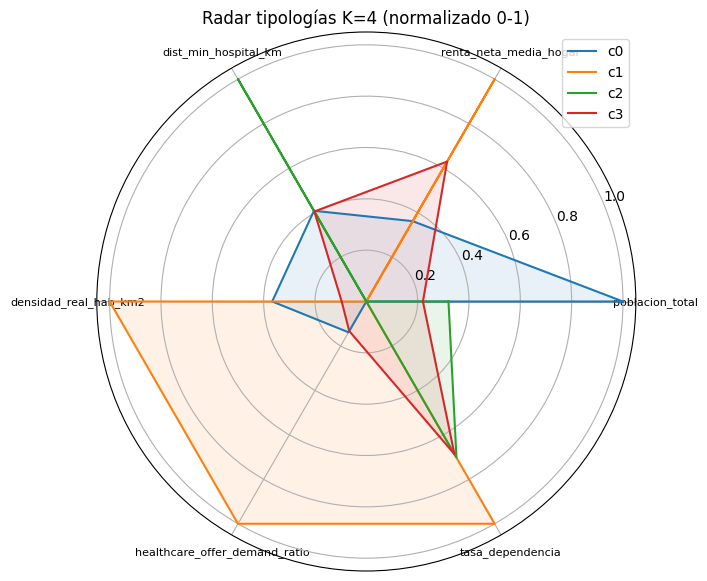

,poblacion_total,renta_neta_media_hogar,dist_min_hospital_km,densidad_real_hab_km2,healthcare_offer_demand_ratio,tasa_dependencia
cluster_label,,,,,,
0,2180.832827,35602.146505,3.501419,8346.809635,0.008969,36.681385
1,1291.592511,37661.931608,0.620434,20481.001443,0.041506,50.098690
2,1576.314103,34436.240032,7.679840,1318.275192,0.003735,46.107270
3,1487.765432,36466.984177,3.478772,3156.365514,0.008759,45.893692


In [32]:
import matplotlib.pyplot as plt
import numpy as np
print("--- Radar perfiles por cluster (6 ejes canónicos) ---")
if 'merged_df' in locals() and 'cluster_label' in merged_df.columns:
    base = ['poblacion_total','renta_neta_media_hogar','dist_min_hospital_km','densidad_real_hab_km2','healthcare_offer_demand_ratio','tasa_dependencia']
    base = [c for c in base if c in merged_df.columns]
    prof = merged_df.groupby('cluster_label')[base].mean()
    # normalizar 0-1 por columna para radar comparable
    norm = (prof - prof.min()) / (prof.max() - prof.min()).replace(0, float('nan'))
    norm = norm.fillna(0.5)
    angles = np.linspace(0, 2*np.pi, len(base), endpoint=False).tolist() + [0]
    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    for k, row in norm.iterrows():
        vals = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, vals, label=f'c{k}')
        ax.fill(angles, vals, alpha=0.1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(base, fontsize=8)
    ax.legend(); plt.title('Radar tipologías K=4 (normalizado 0-1)'); plt.show()
    display(prof)
else: print("Ejecuta K=4 primero (§17c).")
